In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import CSV file in dataframe

In [3]:
df=pd.read_csv('HR_comma_sep.csv')

In [4]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# Data Preprocessing

In [5]:
df.shape

(14999, 10)

In [6]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [10]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [11]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [12]:
df=df.rename(columns={'sales':'department'})

In [13]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [14]:
df.department.value_counts()

department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [16]:
df['department'] = np.where(df['department']=='support','technical',df['department'])
df['department'] = np.where(df['department']=='IT','technical',df['department'])

In [17]:
df.department.value_counts()

department
technical      6176
sales          4140
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

# Check for duplicity

In [18]:
df[df.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1189,0.36,0.51,2,155,3,0,1,0,technical,low
1213,0.38,0.55,2,134,3,0,1,0,technical,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,technical,low
14995,0.37,0.48,2,160,3,0,1,0,technical,low
14996,0.37,0.53,2,143,3,0,1,0,technical,low
14997,0.11,0.96,6,280,4,0,1,0,technical,low


In [19]:
df.drop_duplicates(inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11987 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11987 non-null  float64
 1   last_evaluation        11987 non-null  float64
 2   number_project         11987 non-null  int64  
 3   average_montly_hours   11987 non-null  int64  
 4   time_spend_company     11987 non-null  int64  
 5   Work_accident          11987 non-null  int64  
 6   left                   11987 non-null  int64  
 7   promotion_last_5years  11987 non-null  int64  
 8   department             11987 non-null  object 
 9   salary                 11987 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


# Data Visulization

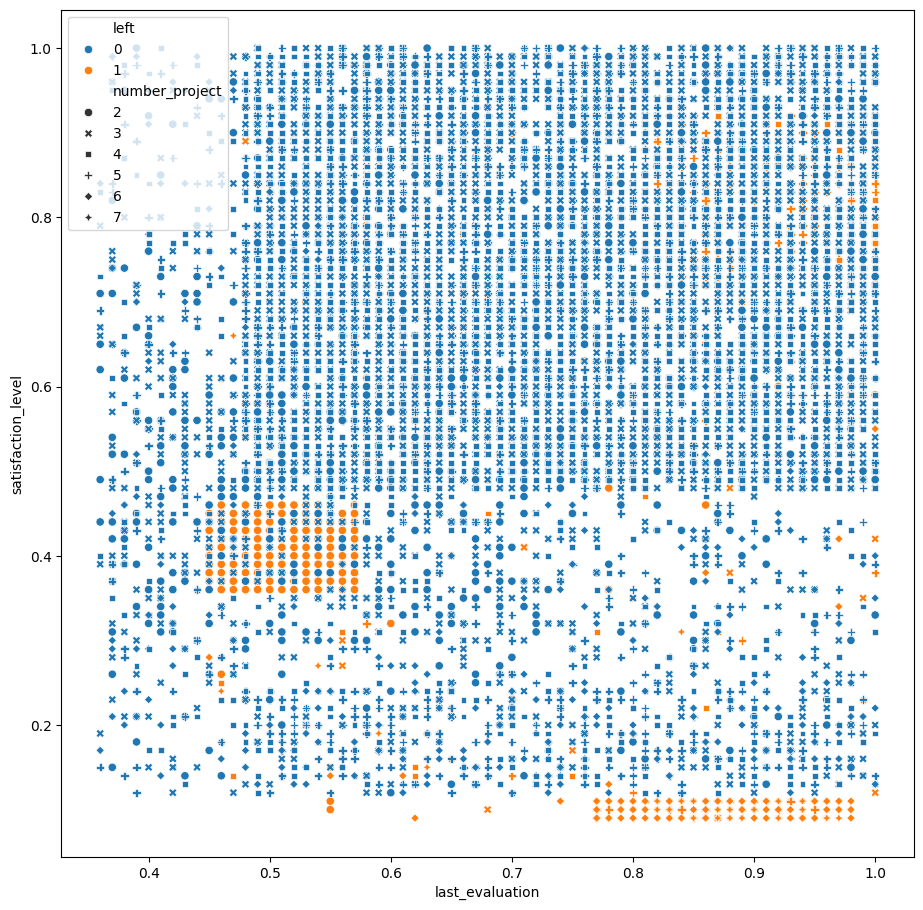

In [35]:
plt.figure(figsize=[11,11])
sns.scatterplot(data=df, x='last_evaluation', y='satisfaction_level', hue='left', style='number_project')
plt.show()

In [51]:
# Employee with <0.6 as last evaluation have low satisfaction level and have high chance to leave tthe organization

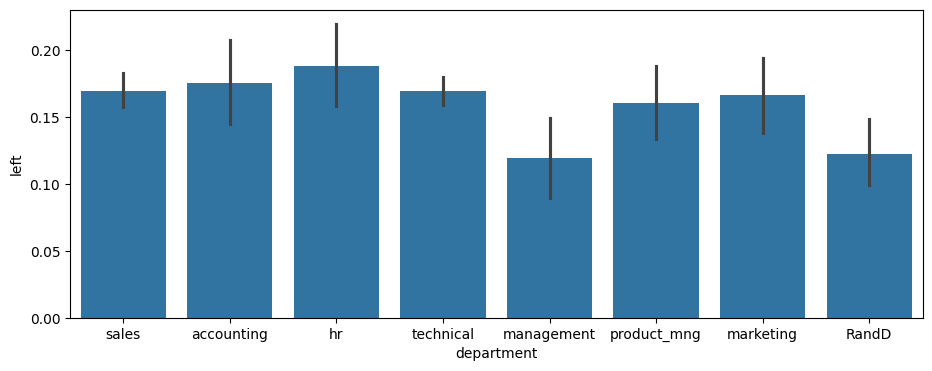

In [33]:
plt.figure(figsize=[11,4])
sns.barplot(data=df, x='department', y='left')
plt.show()

In [50]:
# HR department has maximum attrition rate

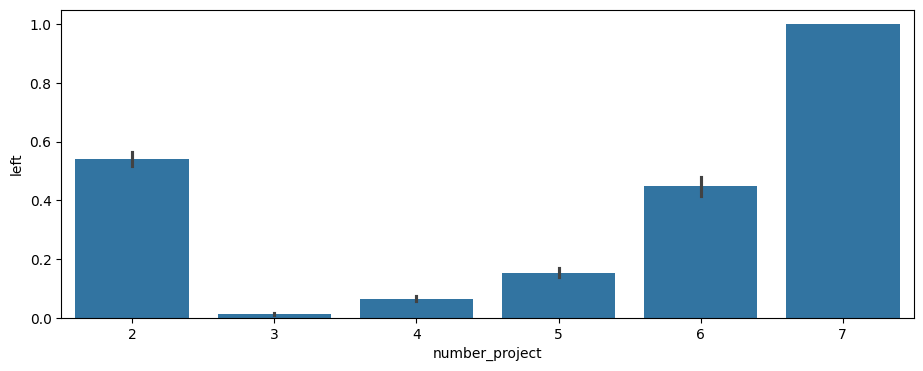

In [25]:
plt.figure(figsize=[11,4])
sns.barplot(data=df, x='number_project', y='left')
plt.show()

In [52]:
# Employee handling high number of project have high chance of leaveing the data

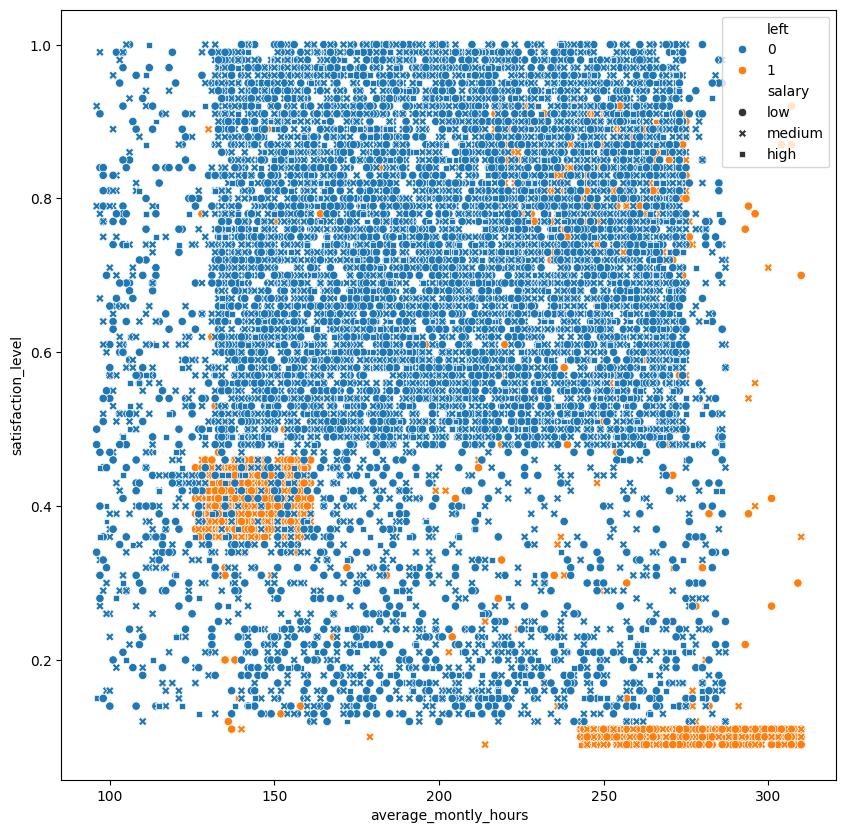

In [37]:
plt.figure(figsize=[10,10])
sns.scatterplot(data=df, x='average_montly_hours', y='satisfaction_level', hue='left', style='salary')
plt.show()

In [53]:
# Employee with high average monthly hours have less satisfaction level

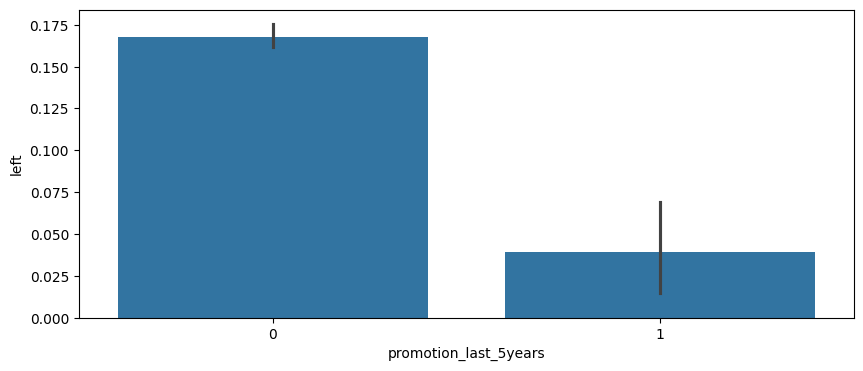

In [41]:
plt.figure(figsize=[10,4])
sns.barplot(data=df, x='promotion_last_5years', y='left')
plt.show()

In [54]:
# Lack of promotion is also a siginificant cause of attrition

In [47]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['department']=le.fit_transform(df['department'])
df['salary']=le.fit_transform(df['salary'])

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11987 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11987 non-null  float64
 1   last_evaluation        11987 non-null  float64
 2   number_project         11987 non-null  int64  
 3   average_montly_hours   11987 non-null  int64  
 4   time_spend_company     11987 non-null  int64  
 5   Work_accident          11987 non-null  int64  
 6   left                   11987 non-null  int64  
 7   promotion_last_5years  11987 non-null  int64  
 8   department             11987 non-null  int64  
 9   salary                 11987 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 1.0 MB


In [49]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,6,1
1,0.80,0.86,5,262,6,0,1,0,6,2
2,0.11,0.88,7,272,4,0,1,0,6,2
3,0.72,0.87,5,223,5,0,1,0,6,1
4,0.37,0.52,2,159,3,0,1,0,6,1


# Check for imbalance data and use SMOTE technique to balance the data

In [55]:
! pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 6.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [56]:
X=df.drop('left', axis=1)
y=df['left']

In [57]:
y.value_counts()

left
0    10000
1     1987
Name: count, dtype: int64

In [ ]:
# We can see a clear imbalance so use SMOTE for oversampling

In [59]:
from imblearn.over_sampling import SMOTE
oversample=SMOTE()
X,y=oversample.fit_resample(X,y)

In [60]:
y.value_counts()

left
1    10000
0    10000
Name: count, dtype: int64

In [61]:
# Now the data is balanced

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build The models and evaluate the models

# 1. Logisitc Regression

In [66]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [67]:
clf.score(X_train, y_train)

0.8043571428571429

In [68]:
clf.score(X_test, y_test)

0.8063333333333333

In [71]:
# Logistic Regression accuracy score is around 80%

# 2. Decision Tree

In [72]:
from sklearn.tree import DecisionTreeClassifier
dt_clf=DecisionTreeClassifier(criterion='entropy')
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [73]:
dt_clf.score(X_train, y_train)

1.0

In [74]:
dt_clf.score(X_test, y_test)

0.958

In [75]:
# The decision Tree model is fitting too good (Overfitting as expected)

# 3. Random Forrest

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
parm = {'n_estimators':[10,20,30,40,50], 'criterion':['gini', 'entropy']}
rf_clf=RandomForestClassifier()
grid=GridSearchCV(estimator=rf_clf, param_grid=parm)
grid.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'n_estimators': [10, 20, 30, 40, 50]})

In [78]:
grid.best_params_

{'criterion': 'gini', 'n_estimators': 50}

In [79]:
grid.best_score_

np.float64(0.9715714285714284)

In [80]:
rf = RandomForestClassifier(n_estimators=50,criterion='gini')
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=50)

In [81]:
rf.score(X_train,y_train)

0.9998571428571429

In [82]:
rf.score(X_test,y_test)

0.9716666666666667

# Cross Validation

In [83]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

In [84]:
cross_val_score(clf,X,y,cv=5).mean()

np.float64(0.8009499999999999)

In [85]:
cross_val_score(dt_clf,X,y,cv=5).mean()

np.float64(0.9498)

In [86]:
cross_val_score(rf,X,y,cv=5).mean()

np.float64(0.97265)

# Confusion Matrix

In [87]:
y_pred=rf.predict(X_test)

In [88]:
confusion_matrix(y_test,y_pred)

array([[3007,   30],
       [ 140, 2823]])

### Correction Areas

In [89]:
# Number of project for employee should be lessen
# HR department should be area of focus
# Salary refinement for mid-salary employee is recommended
# Employee qorking hour should be relaxed